# CAM history-tape diagnostic tests — variable comparison

Analyses the one-day `T0`–`T4` runs produced by `test_diagnostics` (in `cases-scripts/cases-setup.sh`)
and answers three questions from the **actual** h0 files of this NorESM2.3-beta build:

1. **What is the default output pile?**  (`T0`)
2. **Which variables does each flag add?**  `history_aerosol` = `T2 − T0`; `CAM_AEROCOM` = `T3 − T0`.
3. **Does `empty_htapes` win over `history_aerosol`?**  compare `T4` vs `T1`.

This helps to understand which variables I need and which I don't for my analysis.

> Repo hygiene: commit this notebook with outputs cleared
> (`jupyter nbconvert --clear-output --inplace <nb>`), or convert to a script with
> `jupyter nbconvert --to script <nb>`. The real logic lives in the functions cell so it stays reusable.


## 1 · Configuration

In [9]:
from pathlib import Path
import glob

HIST_DIR = Path("/cluster/work/users/adelez/archive")
GLOB_TMPL = "**/*test-{label}*cam.h0*.nc"

# Opt: you can set explicit paths and skip auto-discovery entirely:
#   TEST_FILES = {"T0": "/path/T0....nc", "T1": "...", ...}
TEST_FILES = {}

OUT_DIR = Path("diagnostics_tests_output")
OUT_DIR.mkdir(exist_ok=True)

# Projection: how many h0 records a real production member writes.
# Monthly means (nhtfrq=0, mfilt=1) over a 10-yr member = 12 * 10 = 120 records.
RECORDS_PER_MEMBER = 120

LABELS = ["T0", "T1", "T2", "T3", "T4"]

def resolve_test_files(hist_dir, labels, tmpl, explicit):
    out = {}
    for lab in labels:
        if lab in explicit:
            out[lab] = Path(explicit[lab]); continue
        hits = sorted(Path(hist_dir).glob(tmpl.format(label=lab)))
        if not hits:
            print(f"[skip] {lab}: no file matched {tmpl.format(label=lab)} under {hist_dir}")
            continue
        if len(hits) > 1:
            print(f"[warn] {lab}: {len(hits)} matches, using first -> {hits[0].name}")
        out[lab] = hits[0]
    return out

files = resolve_test_files(HIST_DIR, LABELS, GLOB_TMPL, TEST_FILES)
print("\nresolved:")
for k, v in files.items():
    print(f"  {k}: {v}")


[warn] T0: 2 matches, using first -> NF2000norbc_tropstratchem_nudg_ctrl_f19_f19-test-T0-1day.cam.h0.2000-01-01-00000.nc
[warn] T1: 2 matches, using first -> NF2000norbc_tropstratchem_nudg_ctrl_f19_f19-test-T1-1day.cam.h0.2000-01-01-00000.nc
[warn] T2: 2 matches, using first -> NF2000norbc_tropstratchem_nudg_ctrl_f19_f19-test-T2-1day.cam.h0.2000-01-01-00000.nc
[warn] T3: 2 matches, using first -> NF2000norbc_tropstratchem_nudg_ctrl_f19_f19-test-T3-1day.cam.h0.2000-01-01-00000.nc
[warn] T4: 2 matches, using first -> NF2000norbc_tropstratchem_nudg_ctrl_f19_f19-test-T4-1day.cam.h0.2000-01-01-00000.nc

resolved:
  T0: /cluster/work/users/adelez/archive/NF2000norbc_tropstratchem_nudg_ctrl_f19_f19-test-T0-1day/atm/hist/NF2000norbc_tropstratchem_nudg_ctrl_f19_f19-test-T0-1day.cam.h0.2000-01-01-00000.nc
  T1: /cluster/work/users/adelez/archive/NF2000norbc_tropstratchem_nudg_ctrl_f19_f19-test-T1-1day/atm/hist/NF2000norbc_tropstratchem_nudg_ctrl_f19_f19-test-T1-1day.cam.h0.2000-01-01-00000.nc
  

## 2 · Functions

In [10]:
import numpy as np
import pandas as pd
import xarray as xr

VERTICAL_DIMS = {"lev", "ilev"}   # what counts as "3D" in CAM

def build_var_table(path, test_label=None):
    """One row per *data variable* (coordinates excluded). Metadata only; no data load."""
    ds = xr.open_dataset(path, decode_times=False)
    rows = []
    for name, da in ds.data_vars.items():
        dims  = tuple(da.dims)
        sizes = {d: ds.sizes[d] for d in dims}
        vdim  = next((d for d in dims if d in VERTICAL_DIMS), "")
        nontime = [sizes[d] for d in dims if d != "time"]      # size of ONE time record
        per_step = (int(np.prod(nontime)) if nontime else 1) * da.dtype.itemsize
        rows.append(dict(
            variable=name, dims=",".join(dims), ndim=len(dims),
            is_3d=bool(vdim), vertical=vdim, dtype=str(da.dtype),
            shape=",".join(str(sizes[d]) for d in dims),
            bytes_per_step=per_step, mib_per_step=per_step / 1024**2,
            units=da.attrs.get("units", ""),
            long_name=da.attrs.get("long_name", ""),
            cell_methods=da.attrs.get("cell_methods", ""),
        ))
    ds.close()
    df = pd.DataFrame(rows).sort_values("variable").reset_index(drop=True)
    if test_label:
        df.insert(0, "test", test_label)
    return df

def build_comparison(tables):
    """Union of variables across tests, presence flags T0..T4, size, and 'added_by' classification."""
    all_vars = sorted(set().union(*[set(d.variable) for d in tables.values()]))
    order = [t for t in ["T0", "T2", "T3", "T4", "T1"] if t in tables]   # richest metadata source first
    meta = {}
    for v in all_vars:
        for t in order:
            hit = tables[t][tables[t].variable == v]
            if len(hit):
                meta[v] = hit.iloc[0]; break
    sets = {t: set(d.variable) for t, d in tables.items()}
    rows = []
    for v in all_vars:
        m = meta[v]
        r = dict(variable=v, is_3d=bool(m["is_3d"]), dims=m["dims"],
                 mib_per_step=float(m["mib_per_step"]),
                 units=m["units"], long_name=m["long_name"])
        for t in ["T0", "T1", "T2", "T3", "T4"]:
            r[t] = v in sets.get(t, set())
        rows.append(r)
    comp = pd.DataFrame(rows)
    def classify(r):
        if r["T0"]: return "default"
        ha, ac = r["T2"], r["T3"]
        if ha and ac: return "history_aerosol+aerocom"
        if ha: return "history_aerosol"
        if ac: return "aerocom"
        return "other"
    comp["added_by"] = comp.apply(classify, axis=1)
    return comp.sort_values(["is_3d", "mib_per_step"], ascending=[False, False]).reset_index(drop=True)

def gib_per_member(mib_per_step_sum, records=RECORDS_PER_MEMBER):
    return mib_per_step_sum * records / 1024


## 3 · Load the tests and write per-test CSVs

In [11]:
tables = {}
for lab, path in files.items():
    try:
        tables[lab] = build_var_table(path, lab)
        tables[lab].to_csv(OUT_DIR / f"vars_{lab}.csv", index=False)
    except Exception as e:
        print(f"[error] {lab}: {e}")

print("loaded:", list(tables))


loaded: ['T0', 'T1', 'T2', 'T3', 'T4']


## 4 · Combined comparison table (the master output)

In [12]:
comp = build_comparison(tables)
comp.to_csv(OUT_DIR / "vars_comparison.csv", index=False)
print(f"{len(comp)} variables total across all tests -> {OUT_DIR/'vars_comparison.csv'}")
comp.head(25)


2548 variables total across all tests -> diagnostics_tests_output/vars_comparison.csv


,variable,is_3d,dims,mib_per_step,units,long_name,T0,T1,T2,T3,T4,added_by
0,CLOUDCOVER_CLUBB,True,"time,ilev,lat,lon",1.740234,fraction,Cloud Cover,True,False,True,True,False,default
1,RCMINLAYER_CLUBB,True,"time,ilev,lat,lon",1.740234,g/kg,Cloud Water in Layer,True,False,True,True,False,default
2,RCM_CLUBB,True,"time,ilev,lat,lon",1.740234,g/kg,Cloud Water Mixing Ratio,True,False,True,True,False,default
3,RHO_CLUBB,True,"time,ilev,lat,lon",1.740234,kg/m3,Air Density,True,False,True,True,False,default
4,RTP2_CLUBB,True,"time,ilev,lat,lon",1.740234,g^2/kg^2,Moisture Variance,True,False,True,True,False,default
5,RTPTHLP_CLUBB,True,"time,ilev,lat,lon",1.740234,K g/kg,Temp. Moist. Covariance,True,False,True,True,False,default
6,TH,True,"time,ilev,lat,lon",1.740234,K,Potential Temperature,True,False,True,True,False,default
7,THLP2_CLUBB,True,"time,ilev,lat,lon",1.740234,K^2,Temperature Variance,True,False,True,True,False,default
8,UM_CLUBB,True,"time,ilev,lat,lon",1.740234,m/s,Zonal Wind,True,False,True,True,False,default
9,UP2_CLUBB,True,"time,ilev,lat,lon",1.740234,m2/s2,Zonal Velocity Variance,True,False,True,True,False,default


## 5 · Summary, size projection, and verdicts

In [13]:
def size_line(lab, df):
    return (f"{lab}: {len(df):4d} data-vars | 3D={int(df.is_3d.sum()):3d} "
            f"| {df.mib_per_step.sum():8.3f} MiB/record "
            f"| ~{gib_per_member(df.mib_per_step.sum()):7.2f} GiB/member (uncompressed, {RECORDS_PER_MEMBER} recs)")

print("=== per-test counts & projected member size ===")
for lab in LABELS:
    if lab in tables:
        print(size_line(lab, tables[lab]))

# --- flag blocks ---
if "T0" in tables and "T2" in tables:
    ha = sorted(set(tables["T2"].variable) - set(tables["T0"].variable))
    print(f"\n=== history_aerosol block (T2 - T0): {len(ha)} vars ===")
    print(ha)
if "T0" in tables and "T3" in tables:
    ac = sorted(set(tables["T3"].variable) - set(tables["T0"].variable))
    print(f"\n=== AEROCOM block (T3 - T0): {len(ac)} vars ===")
    print(ac)

# --- empty_htapes verdict ---
if "T1" in tables and "T4" in tables:
    t1, t4 = set(tables["T1"].variable), set(tables["T4"].variable)
    extra = sorted(t4 - t1)
    print("\n=== empty_htapes x history_aerosol verdict ===")
    if not extra:
        print("  T4 == T1  ->  empty_htapes SUPPRESSES history_aerosol defaults. "
              "Clean-slate config works: keep the flag on, list only what you want.")
    else:
        n_ha = len(set(tables['T2'].variable)-set(tables['T0'].variable)) if 'T2' in tables and 'T0' in tables else '?'
        print(f"  T4 has {len(extra)} vars beyond T1 (history_aerosol block ~= {n_ha}).")
        print("  -> empty_htapes does NOT fully suppress history_aerosol; "
              "the flag cannot be retained if a minimal tape is required.")
        print("  extra:", extra[:30], "..." if len(extra) > 30 else "")


=== per-test counts & projected member size ===
T0: 2407 data-vars | 3D=490 |  987.823 MiB/record | ~ 115.76 GiB/member (uncompressed, 120 recs)
T1:   35 data-vars | 3D=  4 |    0.056 MiB/record | ~   0.01 GiB/member (uncompressed, 120 recs)
T2: 2407 data-vars | 3D=490 |  987.823 MiB/record | ~ 115.76 GiB/member (uncompressed, 120 recs)
T3: 2548 data-vars | 3D=541 | 1078.631 MiB/record | ~ 126.40 GiB/member (uncompressed, 120 recs)
T4:   35 data-vars | 3D=  4 |    0.056 MiB/record | ~   0.01 GiB/member (uncompressed, 120 recs)

=== history_aerosol block (T2 - T0): 0 vars ===
[]

=== AEROCOM block (T3 - T0): 141 vars ===
['A550_BC', 'A550_DU', 'A550_POM', 'A550_SO4', 'A550_SS', 'AB550DRY', 'ABS440', 'ABS500', 'ABS550', 'ABS550AL', 'ABS550_A', 'ABS670', 'ABS870', 'ABSDR440', 'ABSDR870', 'ABSDRYAE', 'ABSDRYBC', 'ABSDRYDU', 'ABSDRYOC', 'ABSDRYSS', 'ABSDRYSU', 'AIRMASS', 'AIRMASSL', 'AKCXS', 'ASYMMDRY', 'BATLW01', 'BATOTVIS', 'BATSW13', 'BETOTVIS', 'BS550AER', 'CABS550', 'CABS550A', 'CDOD44

In [14]:
# Size contributed by each source (where the disk actually goes)
if not comp.empty:
    grp = (comp.assign(gib_per_member=lambda d: gib_per_member(d.mib_per_step))
              .groupby("added_by")
              .agg(n_vars=("variable","size"),
                   n_3d=("is_3d","sum"),
                   gib_member=("gib_per_member","sum"))
              .sort_values("gib_member", ascending=False))
    print("=== projected size by source (uncompressed) ===")
    print(grp.to_string())


=== projected size by source (uncompressed) ===
          n_vars  n_3d  gib_member
added_by                          
default     2407   490  115.760495
aerocom      141    51   10.641632


In [19]:
# Heaviest variables overall — the first candidates to scrutinise
if not comp.empty:
    top = comp.assign(gib_member=lambda d: gib_per_member(d.mib_per_step)).head(100)
    display(top[["variable","is_3d","added_by","dims","gib_member","long_name"]])


,variable,is_3d,added_by,dims,gib_member,long_name
0,CLOUDCOVER_CLUBB,True,default,"time,ilev,lat,lon",0.203934,Cloud Cover
1,RCMINLAYER_CLUBB,True,default,"time,ilev,lat,lon",0.203934,Cloud Water in Layer
2,RCM_CLUBB,True,default,"time,ilev,lat,lon",0.203934,Cloud Water Mixing Ratio
3,RHO_CLUBB,True,default,"time,ilev,lat,lon",0.203934,Air Density
4,RTP2_CLUBB,True,default,"time,ilev,lat,lon",0.203934,Moisture Variance
...,...,...,...,...,...,...
95,CCN6,True,default,"time,lev,lat,lon",0.197754,CCN concentration at S=0.5%
96,CCN7,True,default,"time,lev,lat,lon",0.197754,CCN concentration at S=1.0%
97,CF2CLBR,True,default,"time,lev,lat,lon",0.197754,CF2CLBR concentration
98,CF3BR,True,default,"time,lev,lat,lon",0.197754,CF3BR concentration


## 6 · Optional plots

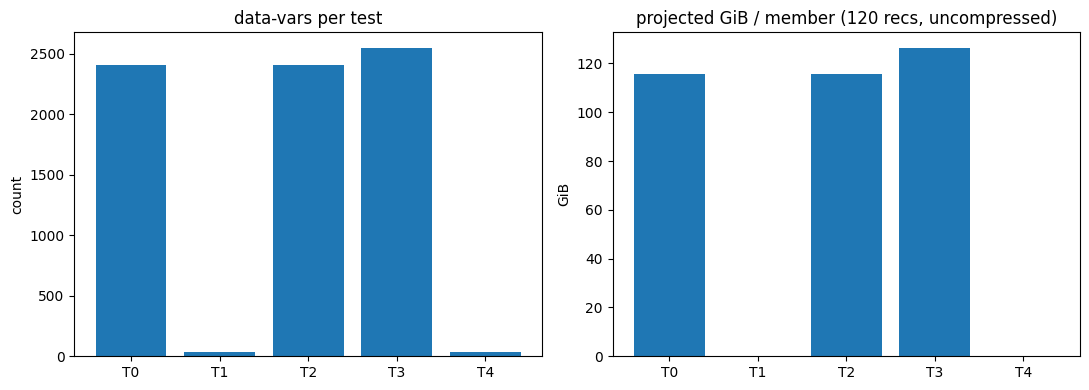

In [16]:
import matplotlib.pyplot as plt

if tables:
    labs = [l for l in LABELS if l in tables]
    nvars = [len(tables[l]) for l in labs]
    gib   = [gib_per_member(tables[l].mib_per_step.sum()) for l in labs]

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].bar(labs, nvars);  ax[0].set_title("data-vars per test"); ax[0].set_ylabel("count")
    ax[1].bar(labs, gib);    ax[1].set_title(f"projected GiB / member ({RECORDS_PER_MEMBER} recs, uncompressed)")
    ax[1].set_ylabel("GiB")
    plt.tight_layout(); plt.show()


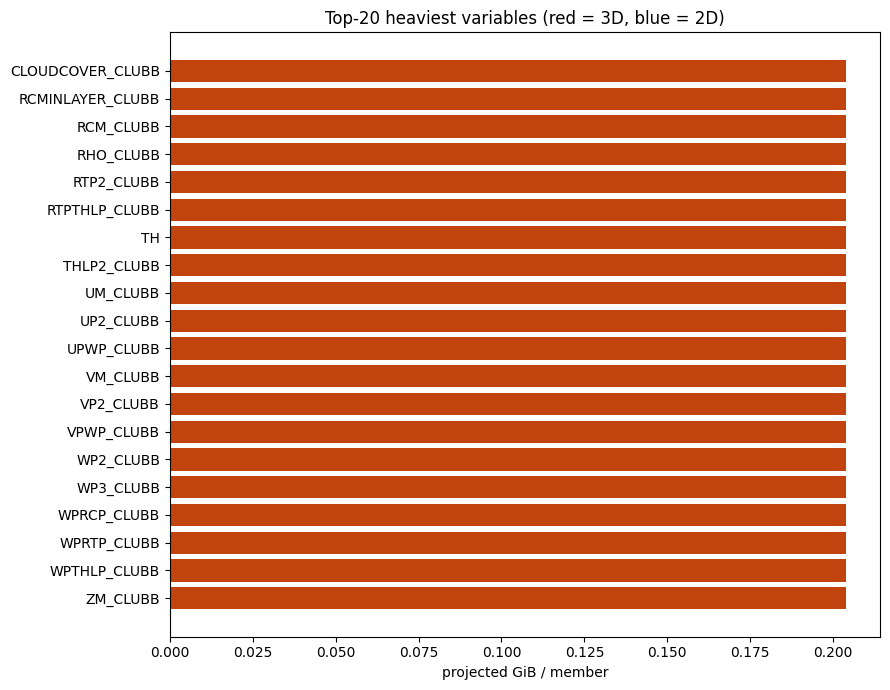

In [17]:
# Top-20 heaviest variables, coloured by 3D vs 2D
if not comp.empty:
    t = comp.assign(gib_member=lambda d: gib_per_member(d.mib_per_step)).head(20).iloc[::-1]
    colors = ["#c1440e" if v else "#4a7ba6" for v in t.is_3d]
    plt.figure(figsize=(9, 7))
    plt.barh(t.variable, t.gib_member, color=colors)
    plt.xlabel("projected GiB / member"); plt.title("Top-20 heaviest variables (red = 3D, blue = 2D)")
    plt.tight_layout(); plt.show()


## 7 · Next step — building the keep-list

`vars_comparison.csv` is now your working surface for deciding the trimmed `fincl`:

- **`added_by`** tells you where each variable comes from (`default` / `history_aerosol` / `aerocom`).
- **`is_3d`** + **`mib_per_step`** tell you what it costs — the 3D rows at the top are the whole budget.
- Filtering, e.g. `comp[(comp.added_by=='aerocom') & comp.is_3d]` shows the heavy AEROCOM optics profiles
  (candidates to drop), while `comp[comp.added_by=='history_aerosol']` shows what you'd lose if the flag
  came off.

From here we map surviving variables to the branches of your feedback diagram (BVOC / SOA / CCN / cloud /
radiative / biogeophysical) and write the `fincl1` + `empty_htapes` config.
